Total training images: 223414

Columns:
['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']

First few rows:
                                                Path     Sex  Age  \
0  CheXpert-v1.0-small/train/patient00001/study1/...  Female   68   
1  CheXpert-v1.0-small/train/patient00002/study2/...  Female   87   
2  CheXpert-v1.0-small/train/patient00002/study1/...  Female   83   
3  CheXpert-v1.0-small/train/patient00002/study1/...  Female   83   
4  CheXpert-v1.0-small/train/patient00003/study1/...    Male   41   

  Frontal/Lateral AP/PA  No Finding  Enlarged Cardiomediastinum  Cardiomegaly  \
0         Frontal    AP         1.0                         NaN           NaN   
1         Frontal    AP         NaN                         NaN          -1.0   
2    

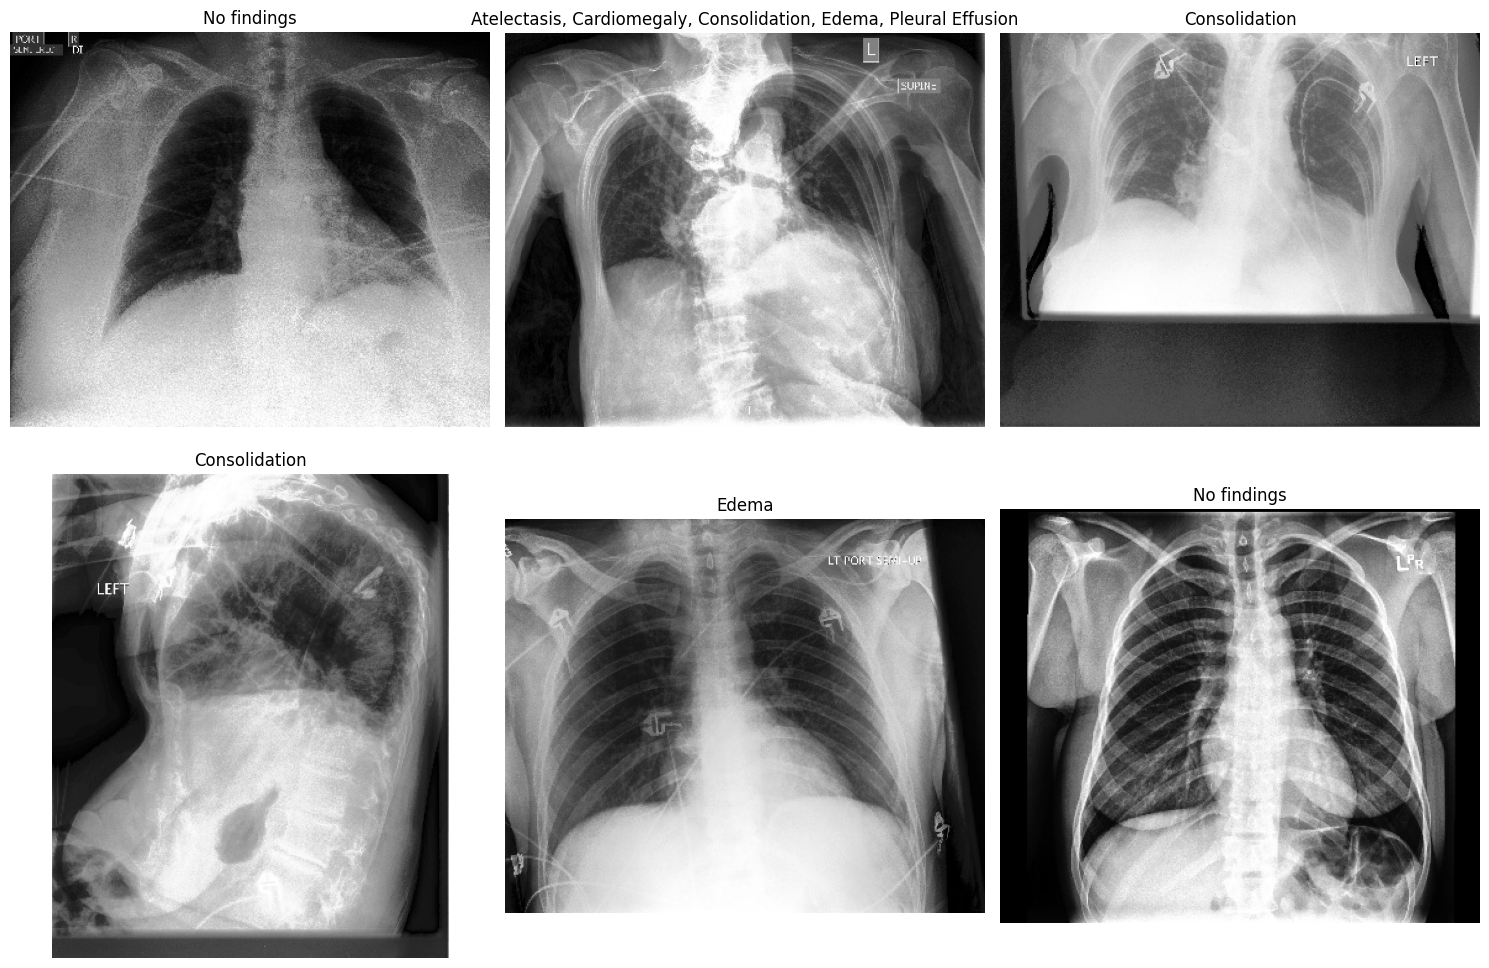

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

train_df = pd.read_csv('../data/train.csv')

print(f"Total training images: {len(train_df)}")
print("\nColumns:")
print(train_df.columns.tolist())

print("\nFirst few rows:")
print(train_df.head())


train_df = train_df.fillna(0)
train_df = train_df.replace(-1.0, 1.0)


disease_cols = [
    'Atelectasis', 
    'Cardiomegaly', 
    'Consolidation', 
    'Edema', 
    'Pleural Effusion'
]

print("\nDisease distribution:")
for disease in disease_cols:
    positive = (train_df[disease] == 1.0).sum()
    print(f"{disease}: {positive} positive cases")

# =========================
# 4. Visualize images
# =========================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i in range(6):
    img_path = train_df.iloc[i]['Path']
    
    # Fix path from CSV → your folder structure
    img_path = img_path.replace("CheXpert-v1.0-small/", "")
    
    # Correct relative path (since notebook is in models/)
    full_path = os.path.join("../data", img_path)
    
    print("Opening:", full_path)
    
    try:
        img = Image.open(full_path).convert("L")  # grayscale
        
        axes[i].imshow(img, cmap='gray')
        
        # Get diseases for this image
        diseases = []
        for disease in disease_cols:
            if train_df.iloc[i][disease] == 1.0:
                diseases.append(disease)
        
        title = ', '.join(diseases) if diseases else 'No findings'
        axes[i].set_title(title)
        axes[i].axis('off')
    
    except Exception as e:
        print(f"Error loading image: {e}")
        axes[i].set_title("Error")
        axes[i].axis('off')

plt.tight_layout()
plt.show()